In [8]:
# load necessary libraries and disable some warnings
import json
import ast
import pandas as pd
import numpy as np
import sys
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer
import torch
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from pathlib import Path

project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.preprocessing import create_category_regex, match_dictionary
from utils.clustering import ModelMask, get_mask_embedding, find_opt_k
from utils.visualizations import plot_clustering_dev, interactive_mentions_boxplot

In [9]:
# load the original groups dictionary
groups_dict_original = pd.read_csv("../01_data/classification/dictionary/groups_dictionary.csv")

# load the main dataframe
main_speech_df = pd.read_csv(
    "../01_data/empirical_analysis/main_speech_datasets/researchperiod_sentencelevel_socialgroups_stances.csv",
    parse_dates=["date", "birth_date"],
    dtype={
        "days_until_election": "int64",
        "agenda": "string",
        "text": "string",
        "sentence": "string",
        "speech_id": "int64",
        "speechnumber": "int64",
        "speaker": "string",
        "party": "category",
        "chair": "boolean",
        "age": "int64",
        "gender": "category",
        "vulnerability": "float64",
        "backbencher": "boolean",
        "constituency_name": "string",
        "ons_id": "string",
        "under_30": "float64",
        "over_65": "float64",
    },
    converters={
        "sg_spans": ast.literal_eval,
        "stances": ast.literal_eval,
    }
)

# reduce df to all speeches given during parliamentary question debates
question_df = main_speech_df[main_speech_df["agenda"].str.contains("question", case=False, na=False)].copy()

# get all detected social group mentions as a df, keep the row id to be able to later match back
question_df_long = question_df.loc[:, ["sg_spans"]].explode("sg_spans").dropna().reset_index(names="row_id")

# create lookup regex and apply to the df
category_regex, group_lookup = create_category_regex(groups_dict_original)

# find dictionary matches and assign the group category
question_df_long[["in_dictionary", "category"]] = question_df_long["sg_spans"].apply(lambda x: pd.Series(match_dictionary(category_regex, group_lookup, x)))

In [10]:
# load the model with pretrained weights from checkpoint
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMask(tokenizer).to(device)
model.load_state_dict(torch.load(f="model_checkpoint/checkpoint.pt", map_location=torch.device("mps")))

# pass all mentions through the model
question_embeddings = get_mask_embedding(model, question_df_long["sg_spans"].tolist(), tokenizer, device)

Optimal k based on Silhouette and NMI score: 53
Silhouette score: 0.5310
NMI score: 0.8899
ARI score: 0.8955


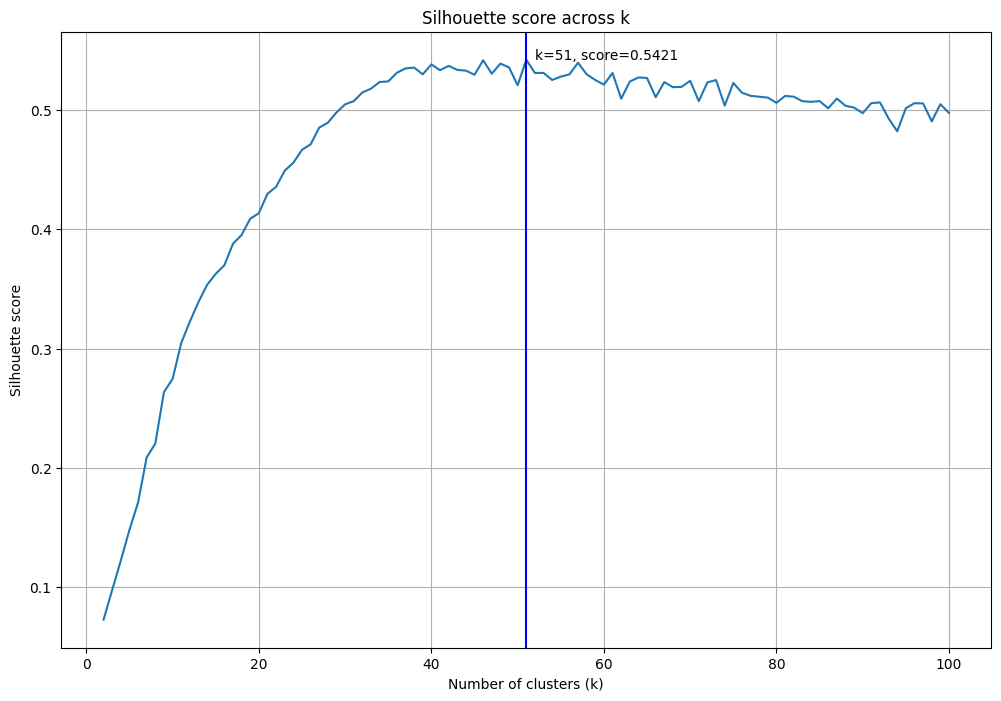

In [16]:
# load evaluation results
with open("clustering_metrics/silhouette_scores_across_k.json", "r") as f:
    cluster_metrics = json.load(f)

ks = list(range(2, 101))
silhouette_scores = cluster_metrics["silhouette_scores"]
nmi_scores = cluster_metrics["nmi_scores"]
ari_scores = cluster_metrics["ari_scores"]

best_k, silscore = find_opt_k(ks, silhouette_scores, nmi_scores, 0.95)

nmi_dict = dict(zip(ks, nmi_scores))
ari_dict = dict(zip(ks, ari_scores))
nmi = nmi_dict[best_k]
ari = ari_dict[best_k]

# print metrics
print(f"Optimal k based on Silhouette and NMI score: {best_k}")
print(f"Silhouette score: {silscore:.4f}")
print(f"NMI score: {nmi:.4f}")
print(f"ARI score: {ari:.4f}")

# plot development of silhouette score over k
_, _ = plot_clustering_dev(ks=ks, metrics_list=silhouette_scores, metric_name="Silhouette", min_max="max", preknown_best_k=None)

In [17]:
# turn to numpy array and run k means with best k found
X = question_embeddings.numpy()
kmeans = KMeans(n_clusters=best_k, random_state=7)

# fit model, predict labels and assign to df
labels = kmeans.fit_predict(X)
question_df_long["cluster"] = labels

# get cluster centroids
centroids = kmeans.cluster_centers_

# cosine distance of each point to its assigned centroid
cos_sim = np.sum(X * centroids[labels], axis=1)
cos_dist = 1 - cos_sim

# assign distances to the df
question_df_long["distance_to_centroid"] = cos_dist

In [31]:
# plot some interactive cluster boxplots
interactive_mentions_boxplot(question_df_long, range(0, 5), mention_col="sg_spans")

In [33]:
# label the data

# create a dictionary for mapping
remap_dict = {
    0: "LGBTQI", 1: "Families", 2: "Criminals", 3: "Women", 4: "Students and practical learners", 5: "Children", 6: "Patients", 7: "Military personnel", 8: "Young people", 9: "Lower class",
    10: "Road users", 11: "Criminal justice staff", 12: "Employers", 13: "Taxpayers", 14: "Healthcare personnel", 15: "Constituents", 16: "Consumers", 17: "Farmers", 18: "Crime victims", 19: "Workers I",
    20: "Ethnic and national communities I", 21: "Education professionals", 22: "People with disabilities", 23: "Local communities", 24: "Citizens", 25: "Unemployed people", 26: "Manual and service workers", 27: "Upper class", 28: "Sociocultural professionals", 29: "Homeowners and landowners",
    30: "White collar workers", 31: "(Nothern-)Irish/Welsh/Scottish people", 32: "Claimants", 33: "Elderly people", 34: "Ethnic and national communities II", 35: "Politicians and voters", 36: "Religious communities", 37: "People in need", 38: "Adults", 39: "Vulnerable people",
    40: "Tenants", 41: "Men", 42: "Rural communities", 43: "Law-enforcement personnel", 44: "Civil servants", 45: "Noise", 46: "Care workers", 47: "Residents of specific constituency", 48: "Investors", 49: "Staff of various professions",
    50: "Migrants and refugees", 51: "Workers II", 52: "Landlords" #, 53: "", 54: "", 55: "", 56: "", 57: "", 58: "", 59: "",
}

# apply the remapping
question_df_long["cluster_label"] = question_df_long["cluster"].map(remap_dict)

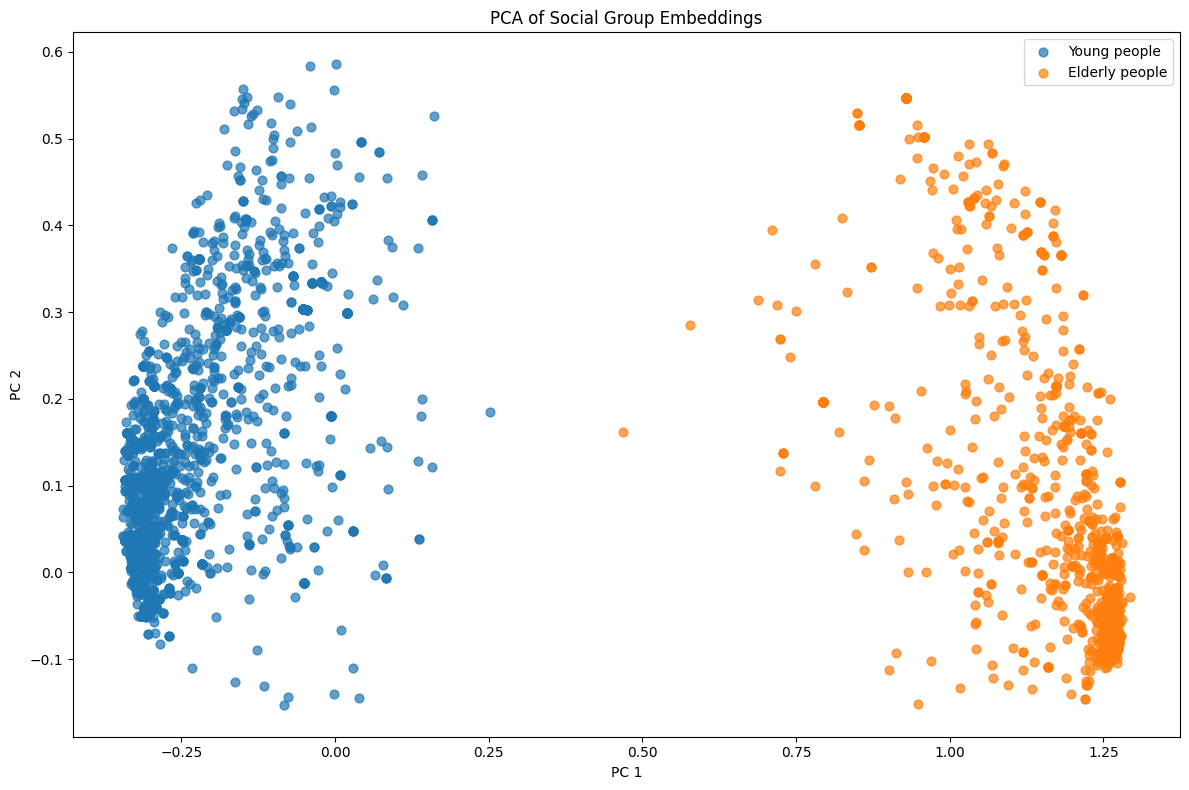

In [57]:
# filter for young and elderly people mentions
young_people_cluster = list(question_df_long.loc[question_df_long["cluster_label"]=="Young people", "sg_spans"])
elderly_people_cluster = list(question_df_long.loc[question_df_long["cluster_label"]=="Elderly people", "sg_spans"])

# get embeddings for these groups
young_people_embeddings = get_mask_embedding(model, young_people_cluster, tokenizer, device)
elderly_people_embeddings = get_mask_embedding(model, elderly_people_cluster, tokenizer, device)

# stack to a numpy array
X = np.vstack([
    young_people_embeddings,
    elderly_people_embeddings
])

labels = np.array(
    ["Young people"] * len(young_people_embeddings)
    + ["Elderly people"] * len(elderly_people_embeddings)
)

# reduce dimension with pca
pca_reducer = PCA(n_components=2, random_state=7)
emb_2d = pca_reducer.fit_transform(X)

# plot all embeddings colored by cluster group
plt.figure(figsize=(12, 8))

for group in ["Young people", "Elderly people"]:
    idx = labels == group
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=group,
        alpha=0.7,
        s=40
    )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.title("PCA of Social Group Embeddings")
plt.tight_layout()
plt.show()

In [43]:
# bind cluster labels back to the main df
sg_categories_by_row = question_df_long.groupby("row_id")["cluster_label"].apply(list)
question_df["sg_categories"] = question_df.index.to_series().map(sg_categories_by_row).apply(lambda x: x if isinstance(x, list) else [])

# remove noise clusters
def remove_noise(sg_spans, stances, sg_categories):
    if not sg_categories:
        return sg_spans, stances, sg_categories

    filtered = [
        (span, stance, cat)
        for span, stance, cat in zip(sg_spans, stances, sg_categories)
        if cat != "Noise"
    ]

    if not filtered:
        return [], [], []

    sg_spans, stances, sg_categories = zip(*filtered)
    return list(sg_spans), list(stances), list(sg_categories)

for idx in question_df.index:
    sg_spans = question_df.at[idx, "sg_spans"]
    stances = question_df.at[idx, "stances"]
    sg_categories = question_df.at[idx, "sg_categories"]

    sg_spans, stances, sg_categories = remove_noise(
        sg_spans, stances, sg_categories
    )

    question_df.at[idx, "sg_spans"] = sg_spans
    question_df.at[idx, "stances"] = stances
    question_df.at[idx, "sg_categories"] = sg_categories

# reorder the columns
cols_reorder = ["date", "days_until_election", "agenda", "text", "sentence", "sg_spans", "stances", "sg_categories", "speech_id", "speechnumber", "speaker", "party", "chair", "age", "gender", "birth_date", "vulnerability", "backbencher", "constituency_name", "ons_id", "under_30", "over_65"]
question_df = question_df.loc[:, cols_reorder]

# export as a csv
#question_df.to_csv("../01_data/empirical_analysis/speech_data_clusterlabels/parl_questions_clusterlabels.csv")